# Visualizing the Cube

<div class="page-subtitle">
From static verification to interactive exploration
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/12_L10_time-series/03_visualizing_the_cube.ipynb)

---

```{admonition} Big idea
:class: tip

Visualization is the fastest way to verify data integrity. Before analyzing your data, you should always plot it to spot extreme outliers, validate spatial patterns, and check seasonal cycles.
```

As a spatial data scientist, you are already familiar with analyzing raster data. However, visualizing multidimensional arrays in Python requires learning some new syntax. Fortunately, `xarray` acts as a highly intelligent wrapper around the standard `matplotlib` library. Because your data cube contains named dimensions, coordinates, and metadata, `xarray` automatically labels your axes, generates color bars, and formats dates. You rarely need to write boilerplate visualization code.

This chapter transitions through the complete visualization workflow. We begin with rapid static plots for data validation, move to multidimensional faceting, add geographic projections, and finally explore the cube dynamically using interactive browser tools.

As in the previous chapter, we will use the National Centers for Environmental Prediction (NCEP) surface air temperature dataset for these examples.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the tutorial dataset
ds = xr.tutorial.open_dataset("air_temperature")

---

## 1. Basic Plotting

The `.plot()` method is your primary tool for rapid data validation. By default, `xarray` inspects the dimensionality of your data array and automatically chooses the most appropriate plot type. It defaults to a line plot for 1D arrays, a heatmap for 2D arrays, and a histogram for everything else. Because this method wraps `matplotlib`, all your existing visualization knowledge carries over seamlessly.

### Histograms
To spot erroneous values, such as a sensor error recording a fill value of 9999, it is highly useful to check the overall data distribution. When you call `.plot()` on a 3D array, `xarray` automatically flattens the data and generates a histogram. You can pass standard `matplotlib` keyword arguments directly into this method to customize the look.

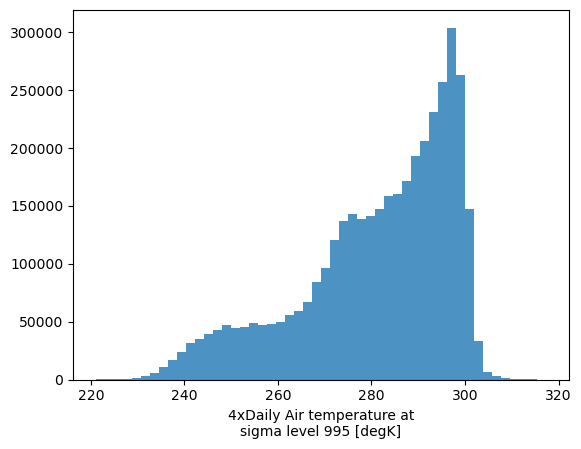

In [2]:
# Plot a histogram with 50 bins to check the overall data distribution
ds.air.plot.hist(bins=50, histtype="stepfilled", alpha=0.8)
plt.show()

<div class="figure-caption-like">
A standard histogram of the temperature data. The axes and labels are automatically extracted from the dataset metadata.
</div>

### Time Series
If you extract a single spatial location over time, `xarray` detects the 1D data and defaults to a line plot (`.plot.line()`). This is incredibly useful for verifying temporal patterns. 

You can easily plot multiple lines on the same chart to compare locations. By passing a list of coordinates to `.sel()` and specifying the `hue` argument, `xarray` handles the grouping and coloring automatically.

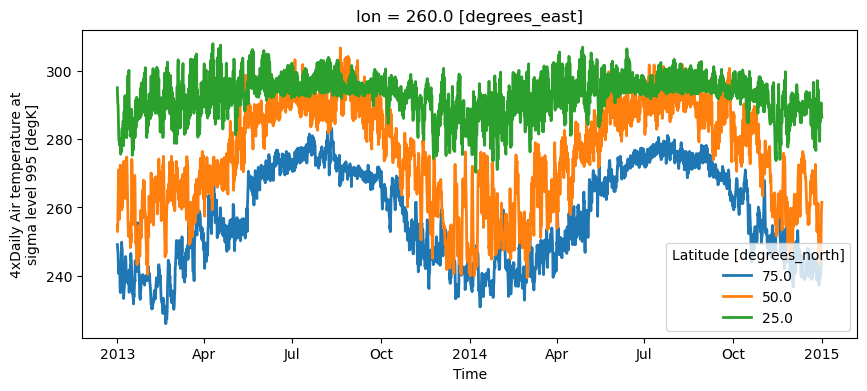

In [3]:
# Extract temperatures at three different latitudes and plot them together
ds.air.sel(lat=[75.0, 50.0, 25.0], lon=260.0, method="nearest").plot.line(
    x="time", hue="lat", figsize=(10, 4), linewidth=2
)
plt.show()

<div class="figure-caption-like">
Comparing temperature cycles across different latitudes. The hue argument automatically generates a legend distinguishing the spatial coordinates.
</div>

### Slicing 2D Maps
You cannot plot a full 3D cube on a flat screen. To map the spatial data, you must isolate a single slice of time. `xarray` automatically recognizes the two remaining spatial dimensions and generates a color mesh heatmap using the underlying `.plot.pcolormesh()` function.

You can heavily customize these maps using dictionaries like `cbar_kwargs` to format the colorbar, or overlay additional information, such as a contour plot, directly on top of your base map for added detail.

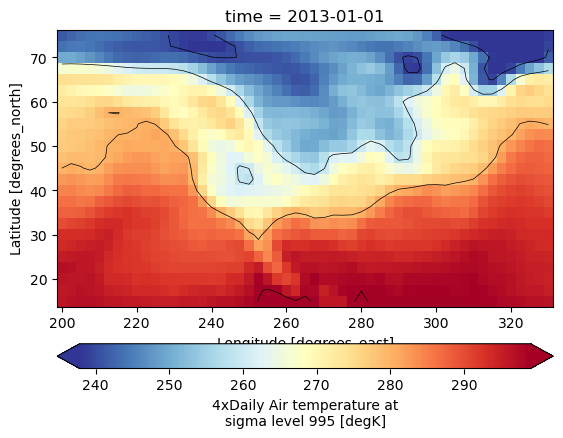

In [4]:
# 1. Plot the base heatmap with robust color limits and a horizontal colorbar
ds.air.isel(time=0).plot.pcolormesh(
    robust=True, cmap="RdYlBu_r", cbar_kwargs={"orientation": "horizontal", "pad": 0.1}
)

# 2. Overlay a contour plot on the same axis
ds.air.isel(time=0).plot.contour(colors="k", levels=5, linewidths=0.5)

plt.show()

<div class="figure-caption-like">
A single time slice plotted as a 2D map. Adding robust=True calculates the color range based on the 2nd and 98th percentiles, cleanly hiding extreme anomalies.
</div>

---

## 2. Multidimensional Visualizations

When you want to visualize the third dimension without slicing it away completely, you can use faceting. Faceting is the art of presenting small multiples of your data in a clean grid. This is particularly effective for observing spatial changes over time.

### Faceting
Instead of one single map, `xarray` can generate a grid of subplots that all share the exact same color scale and geographic extent. You simply tell the `.plot()` method which dimension should be spread across the columns using the `col` argument. 

Because faceted plots can easily become cramped, it is common practice to pass a dictionary of `cbar_kwargs` to move the shared colorbar to the bottom of the figure.

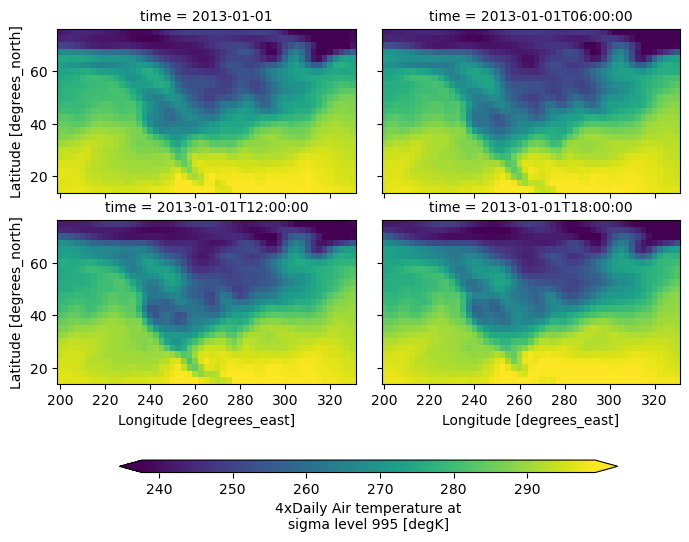

In [5]:
# Select the first 4 time steps and plot them adjacent to each other
ds.air.isel(time=slice(0, 4)).plot(
    col="time",
    col_wrap=2,
    robust=True,
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.8, "aspect": 40},
)
plt.show()

<div class="figure-caption-like">
Faceted subplots allow you to easily compare spatial patterns across the time dimension. The col_wrap argument forces the grid onto a new row, and the colorbar is formatted to sit cleanly below the grid.
</div>

### Advanced Customizations
When you create a faceted plot, `xarray` returns a `FacetGrid` object. This object acts as a powerful master controller for the entire grid, giving you access to properties like `fg.fig` (the overall figure) and methods like `fg.set_xlabels()`.

Most importantly, you can use `.map()` or `.map_dataarray()` to apply a custom `matplotlib` or `xarray` plotting function to every single panel simultaneously. For example, you can easily overlay topographic contours or a specific point of interest across all time steps.

TypeError: FacetGrid.map_dataarray() missing 2 required positional arguments: 'x' and 'y'

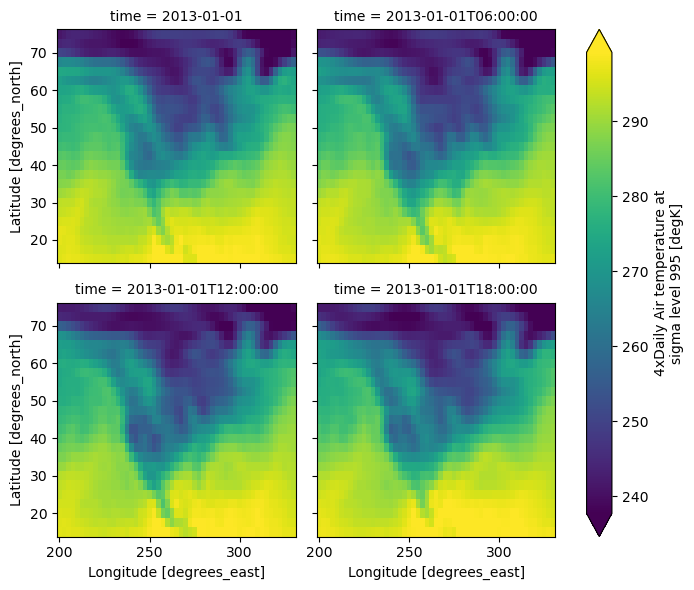

In [6]:
fg = ds.air.isel(time=slice(0, 4)).plot(col="time", col_wrap=2, robust=True)

# Map a contour plot onto every panel using the original DataArray
fg.map_dataarray(
    xr.plot.contour, colors="k", levels=5, linewidths=0.5, add_colorbar=False
)

# Map a standard matplotlib point marker onto every panel
fg.map(lambda: plt.plot(260.0, 40.0, marker="*", color="white", markersize=15))

plt.show()

<div class="figure-caption-like">
Using the FacetGrid object to map contours and a specific white star marker across every subplot simultaneously.
</div>

### Faceting Multiple Variables
You are not limited to faceting along existing dimensions like time or elevation. You can actually facet entirely different variables against each other. If you convert a `Dataset` container into a single `DataArray` using `.to_array()`, your variable names become a brand new dimension that you can use in your facet grid.

```{admonition} Shared Color Scales
:class: warning

You should only facet multiple variables together if it makes physical sense for them to share the exact same color scale. For example, you should never facet Temperature [Celsius] and Precipitation [mm] together. However, plotting the horizontal and vertical gradients of temperature together works perfectly because they share the same units.
```

In [ ]:
# Calculate spatial temperature gradients
ds["dTdx"] = ds.air.differentiate("lon")
ds["dTdy"] = ds.air.differentiate("lat")

# Convert the two new variables into a single DataArray
gradients = ds[["dTdx", "dTdy"]].to_array("gradient_direction")

# Facet the variables (rows) against the time dimension (columns)
fg = gradients.isel(time=slice(0, 3)).plot(
    col="time", row="gradient_direction", robust=True, cmap="coolwarm"
)

plt.show()

<div class="figure-caption-like">
Comparing horizontal and vertical temperature gradients over time. The variables are split across the rows, while the time steps are split across the columns.
</div>

---

## 3. Geographic Context

While `xarray` correctly labels the axes with latitude and longitude coordinates, the plot itself lacks physical geographic context. Since `xarray` builds directly on `matplotlib`, you can seamlessly integrate the `cartopy` library to project your raw matrices onto real Earth cartography.

### Plotting a Single Map
Adding cartographic projections to a single plot requires three specific steps. First, you set up a matplotlib axis with a specific projection. Second, you plot the data while declaring the original Coordinate Reference System of your raw data using the `transform` argument. Third, you draw geographic features onto the axis.

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# 1. Set up a figure and axis with a specific map projection
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Orthographic(-90, 30)})

# 2. Plot the data, telling Cartopy the raw data is in Lat/Lon (PlateCarree)
ds.air.isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    robust=True,
    cmap="inferno",
    cbar_kwargs={"shrink": 0.7},
)

# 3. Add coastlines to the axis to provide geographic context
ax.coastlines()

plt.show()

<div class="figure-caption-like">
By combining xarray with cartopy, the raw data matrix is projected onto a recognizable Earth surface. The transform argument ensures the raw grid points are mapped to the correct physical locations.
</div>

### Faceting Geographic Maps
You can easily combine the power of faceting from the previous section with Cartopy projections. 

Because `xarray` generates the subplot axes for you automatically when faceting, you cannot create the axes manually like we did above. Instead, you pass the projection inside the `subplot_kws` dictionary. Finally, you can use the `FacetGrid.map()` method you learned earlier to apply coastlines to every single panel simultaneously.

In [ ]:
# Create a faceted grid with a Lambert Conformal projection
fg = ds.air.isel(time=slice(0, 3)).plot(
    col="time",
    transform=ccrs.PlateCarree(),  # Remember to provide the raw data projection!
    subplot_kws={
        "projection": ccrs.LambertConformal(central_longitude=-95, central_latitude=45)
    },
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.8, "aspect": 40},
    robust=True,
    cmap="inferno",
)

# Apply a coastline to every single axis in the facet grid
fg.map(lambda: plt.gca().coastlines())

plt.show()

<div class="figure-caption-like">
Faceted maps projected over North America using Cartopy. The map function ensures that the coastlines are drawn across all time steps perfectly.
</div>

### Animating the time dimension (GIFs)

Faceted plots are great for comparing a few time steps, but if you want to visualize an entire year of data, a static grid is no longer sufficient. Because your data cube inherently understands the progression of time, you can easily generate an animated GIF. 

The standard approach uses the `matplotlib.animation` tool. The logic is simple: you create an empty figure, define an `update` function that plots a single time slice, and then tell Python to loop that function across a set number of frames.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Set up the figure and axes
fig, ax = plt.subplots(figsize=(8, 5))


# 2. Define the function that will update the map for every frame
def animate_frame(i):
    ax.clear()  # Clear the previous map

    # Isolate the current time step and plot it
    # We set add_colorbar=False so it doesn't draw a new one every frame
    ds.air.isel(time=i).plot(ax=ax, add_colorbar=False, robust=True)

    # Add a dynamic title showing the exact date
    current_date = ds.air.time.values[i]
    ax.set_title(f"Temperature on {str(current_date)[:10]}")


# 3. Create the animation (e.g., for the first 20 time steps)
ani = animation.FuncAnimation(fig, animate_frame, frames=20, interval=200)

# 4. Save the result as a GIF using the Pillow writer
ani.save("temperature_timelapse.gif", writer="pillow")

plt.close()  # Prevents the static plot from showing up in the notebook

<div class="figure-caption-like">
By animating the time dimension, you can visually track dynamic environmental processes like the progression of seasons, the movement of storm systems, or extreme seasonal temperature shifts.
</div>

:::{figure} images/08_temperature_timelapse.gif
:alt: An animated GIF showing temperature patterns shifting across the globe over 20 consecutive days.
:width: 600px
:align: center

*By animating the time dimension, you can visually track dynamic environmental processes like the progression of seasons, the movement of storm systems, or the expansion of urban heat waves.*
:::

```{admonition} Performance warning
:class: warning

Generating a GIF is computationally heavy because Python has to render a brand new map for every single frame. Start by testing your animation on a small slice of time (e.g., `frames=20`) before trying to animate an entire multi-year data cube!
```

## 4. Interactive Exploration

Static matplotlib plots are excellent for documentation and publications, but exploring a massive data cube requires dynamic interaction. The holoviews ecosystem provides an interactive alternative called `hvplot`. These plots build directly on the Bokeh library to output interactive, browser native widgets rather than static images.

### Introduction to hvplot
The `hvplot` library makes use of the `xarray` accessor interface. Once you run `import hvplot.xarray`, every `xarray` object gains an `.hvplot()` method that behaves almost identically to the standard `.plot()` syntax. Just like the basic plotting tools, it makes the same default choices: a 1D array yields a line plot, and a 2D array yields a quadmesh heatmap.

In [ ]:
import hvplot.xarray

### Interactive Sliders
Where `hvplot` truly shines is in its interactivity. By passing the entire data cube to `.hvplot()` and specifying a dimension in the `groupby` argument, the library automatically generates a user interface slider. This allows you to smoothly scrub through the time dimension. 

It is highly recommended to set constant colorbar limits using the `clim` argument. If you skip this step, the color mapping will recalculate for every single frame, making visual comparisons across time impossible.

In [ ]:
# Generate an interactive map with a time slider
ds.air.hvplot(groupby="time", clim=(230, 300), cmap="viridis")

<div class="figure-caption-like">
An interactive heatmap with a built-in time slider. Grouping by the time dimension allows you to manually scrub through the dataset, while the constant color limits ensure accurate visual comparisons.
</div>

### Animations
You can easily upgrade the manual slider into a playback animation. By specifying `widget_type="scrubber"`, the map will play forward automatically, revealing dynamic environmental processes. You can also control the placement of this tool using the `widget_location` argument.

In [ ]:
# Convert the slider into an automatic playback scrubber
ds.air.hvplot(
    groupby="time",
    clim=(230, 300),
    cmap="viridis",
    widget_type="scrubber",
    widget_location="bottom",
)

<div class="figure-caption-like">
A playback scrubber widget. This upgrades the manual slider into a fully animated interface, making it easier to spot continuous environmental trends over time.
</div>

### Geographic Maps
Finally, you can seamlessly combine the interactivity of `hvplot` with the geographic projections of `cartopy`. By passing the `projection` and `coastline=True` arguments directly into the `.hvplot()` call, you create a map that supports panning, zooming, and hover tooltips to inspect exact pixel values.

In [ ]:
# Create an interactive globe with hover capabilities
import cartopy.crs as ccrs

ds.air.isel(time=0).hvplot(
    projection=ccrs.Orthographic(-90, 30), coastline=True, cmap="inferno"
)

<div class="figure-caption-like">
An interactive geographic globe. By integrating Cartopy projections with hvplot, you gain the ability to pan, zoom, and hover over specific pixels to read their exact coordinate and temperature values.
</div>

---

## 5. Exercise: Interactive {abbr}`SST (Sea Surface Temperature)`

It is time to practice interactive visualization with a real data cube. `xarray` includes a tutorial dataset called `ersstv5`, which contains monthly global **sea surface temperature** observations.

Your task is to turn this dataset into an interactive map that allows you to explore how sea surface temperature changes through time.

**Your task:**
1. **Open:** Load the `ersstv5` dataset using `xr.tutorial.open_dataset()`.
2. **Select:** Extract the sea surface temperature variable `sst`.
3. **Plot:** Use `.hvplot()` to create an interactive map grouped by the `time` dimension.
4. **Animate:** Set the `widget_type` so the map can be explored with a time scrubber.
5. **Stabilize:** Use a fixed colormap range with `clim=(0, 30)` and the colormap `coolwarm`. If you skip this, the color scaling will change from frame to frame and make comparison much harder.
6. **Format:** Set a clear title and a figure size that makes the global map easy to inspect.

**Starter code:**

In [ ]:
import xarray as xr
import hvplot.xarray

# 1. Open the dataset
# ...

# 2. Extract the sea surface temperature variable
# ...

# 3. Create the interactive plot
# ...

````{admonition} Sample solution
:class: dropdown

```{code-cell} python
import xarray as xr
import hvplot.xarray

# 1. Open the dataset
ds = xr.tutorial.open_dataset("ersstv5")

# 2. Extract the sea surface temperature variable
sst = ds["sst"]

# 3. Create the interactive plot
sst.hvplot(
    groupby="time",
    widget_type="scrubber",
    cmap="coolwarm",
    clim=(0, 30),
    width=800,
    height=600,
    title="Sea Surface Temperature"
)
```

:::{figure} images/12_ex_sst_hvplot.png
:alt: An interactive global map of sea surface temperature, displayed with a time scrubber and a coolwarm color scale.
:width: 700px
:align: center

*Output: An interactive global map of sea surface temperature. The scrubber allows you to move through time, while the fixed color scale makes changes comparable across all frames.*
:::

**Notice the fixed color scale:** Because the same color range is used for every time step, you can compare warm and cold ocean regions much more reliably across time. Without a fixed `clim`, the map would keep rescaling itself and visual comparison would become much harder.
``` 
````

---

## 6. Summary

Visualizing data cubes efficiently requires selecting the right tool for the specific task at hand. By mastering the `xarray` visualization ecosystem, you can seamlessly transition from quick data checks to fully interactive applications.

* **Static Validation:** Use the standard `.plot()` method (histograms, line plots, 2D heatmaps) to quickly verify data distributions and spot extreme outliers.
* **Multidimensional Comparison:** Use faceting to generate grids of subplots. The `FacetGrid` object is perfect for observing spatial changes over time on a shared color scale.
* **Geographic Context:** Integrate the `cartopy` library to accurately project your raw data matrices onto recognizable Earth cartography.
* **Animations:** Use `matplotlib.animation` to generate GIFs and visually track dynamic environmental processes over long time series.
* **Interactive Exploration:** Switch to `.hvplot()` to generate browser-native widgets, enabling dynamic time scrubbers and interactive tools like panning, zooming, and hover tooltips.

With a firm grasp on how to inspect and visualize multidimensional arrays, you are now ready to apply deeper mathematical operations and reductions to your data cubes in the following chapters.